 Roommate Dataset — Full Data Analysis

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Global plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

BLUE   = '#4C78A8'
CORAL  = '#E45756'
GREEN  = '#54A24B'
PURPLE = '#7B4173'
AMBER  = '#F58518'

print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
df = pd.read_csv('user_big2.csv')

print(f'\n Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'\n Columns       : {df.columns.tolist()}')
print(f'\n Numeric cols  : {df.select_dtypes(include=np.number).columns.tolist()}')
print(f' Text cols     : {df.select_dtypes(exclude=np.number).columns.tolist()}')


 Dataset shape : 5,002 rows × 12 columns

 Columns       : ['user_id', 'age', 'gender', 'occupation', 'smoking_status', 'pet_status', 'sleep_schedule', 'cleanliness', 'budget_min', 'budget_max', 'roommate_gender_pref', 'pref_smoking']

 Numeric cols  : ['user_id', 'age', 'cleanliness', 'budget_min', 'budget_max']
 Text cols     : ['gender', 'occupation', 'smoking_status', 'pet_status', 'sleep_schedule', 'roommate_gender_pref', 'pref_smoking']


In [3]:
# Statistical summary of numeric columns
# Mean, std, min/max tell us the spread and typical values for age, budget, cleanliness
df.describe().round(2)

,user_id,age,cleanliness,budget_min,budget_max
count,5002.00,5002.00,5002.00,5002.00,5002.00
mean,2501.50,26.57,3.01,2756.63,4495.13
std,1444.10,5.19,1.41,725.62,1017.48
min,1.00,18.00,1.00,1500.00,2016.00
25%,1251.25,22.00,2.00,2117.25,3764.25
50%,2501.50,27.00,3.00,2771.00,4505.50
75%,3751.75,31.00,4.00,3385.75,5229.00
max,5002.00,35.00,5.00,3998.00,6935.00


In [ ]:
# Unique value count per column
# High unique count = continuous variable >> Low = categorical.
print('Unique values per column:')
for col in df.columns:
    print(f'  {col:<25} {df[col].nunique():>5} unique')

Unique values per column:
  user_id                    5002 unique
  age                          18 unique
  gender                        2 unique
  occupation                    8 unique
  smoking_status                2 unique
  pet_status                    2 unique
  sleep_schedule                2 unique
  cleanliness                   5 unique
  budget_min                 2192 unique
  budget_max                 2824 unique
  roommate_gender_pref          3 unique
  pref_smoking                  2 unique


In [24]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing)
print(f'\nDuplicate rows: {df.duplicated().sum()}')


Missing values per column:
user_id                 0
age                     0
gender                  0
occupation              0
smoking_status          0
pet_status              0
sleep_schedule          0
cleanliness             0
budget_min              0
budget_max              0
roommate_gender_pref    0
pref_smoking            0
budget_gap              0
dtype: int64

Duplicate rows: 0


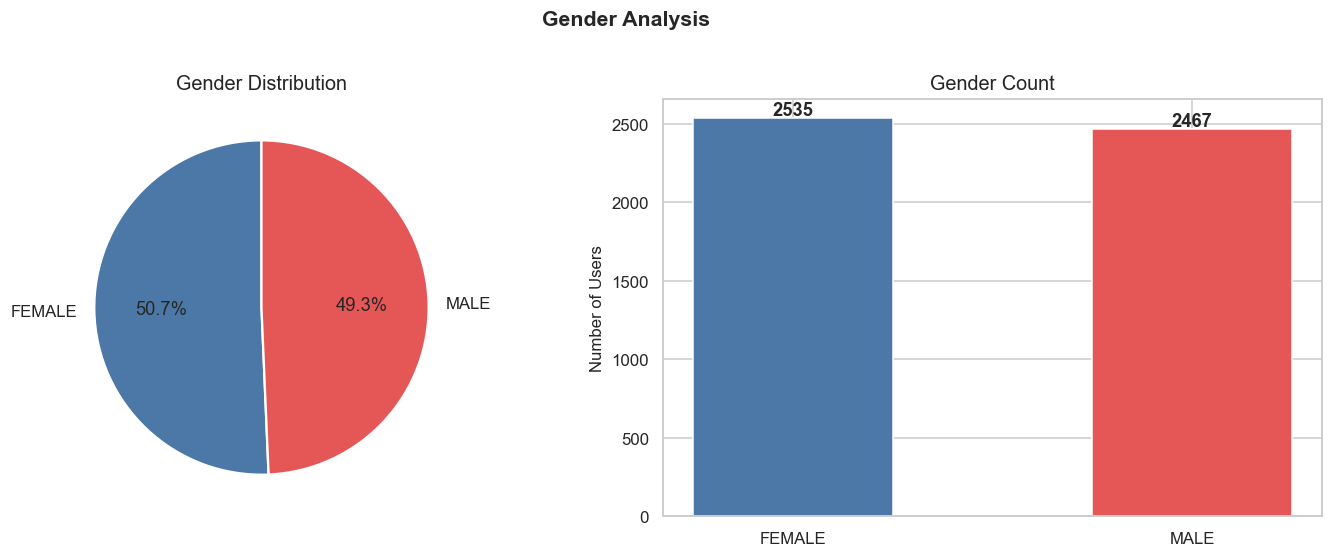

In [25]:
gender_counts = df['gender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=[BLUE, CORAL], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Gender Distribution')

axes[1].bar(gender_counts.index, gender_counts.values, color=[BLUE, CORAL], edgecolor='white', width=0.5)
axes[1].set_title('Gender Count')
axes[1].set_ylabel('Number of Users')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Gender Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

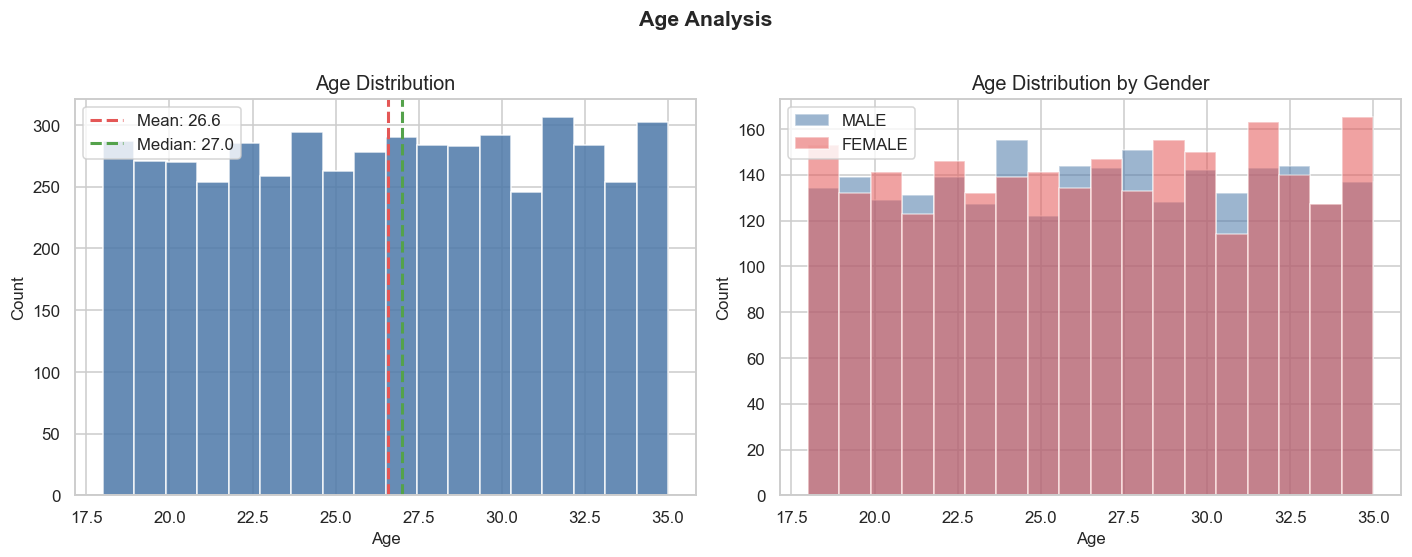

Age range  : 18 – 35
Mean age   : 26.6
Median age : 27.0


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['age'], bins=18, color=BLUE, edgecolor='white', alpha=0.85)
axes[0].axvline(df['age'].mean(), color=CORAL, linestyle='--', linewidth=2, label=f"Mean: {df['age'].mean():.1f}")
axes[0].axvline(df['age'].median(), color=GREEN, linestyle='--', linewidth=2, label=f"Median: {df['age'].median():.1f}")
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Age by gender — overlapping KDE
for g, c in zip(['MALE', 'FEMALE'], [BLUE, CORAL]):
    axes[1].hist(df[df['gender'] == g]['age'], bins=18, alpha=0.55,
                 label=g, color=c, edgecolor='white')
axes[1].set_title('Age Distribution by Gender')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.suptitle('Age Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Age range  : {df['age'].min()} – {df['age'].max()}")
print(f"Mean age   : {df['age'].mean():.1f}")
print(f"Median age : {df['age'].median():.1f}")

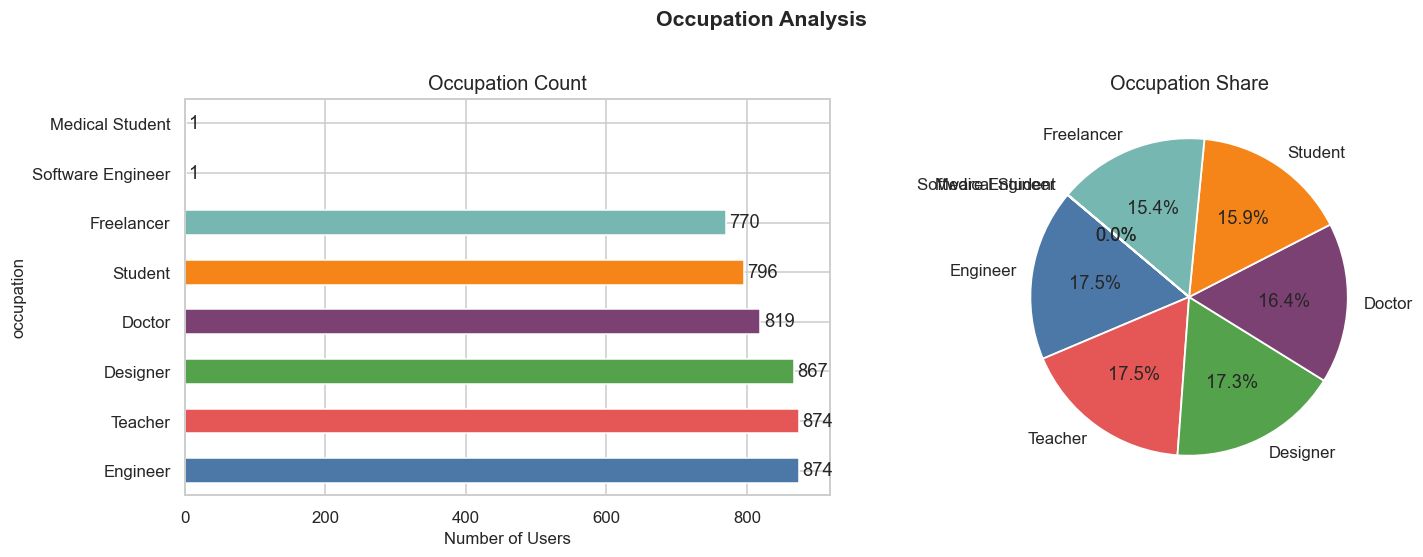

In [28]:
 
occ_counts = df['occupation'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = [BLUE, CORAL, GREEN, PURPLE, AMBER, '#76B7B2', '#FF9DA7', '#BAB0AC']
occ_counts.plot(kind='barh', ax=axes[0], color=colors[:len(occ_counts)], edgecolor='white')
axes[0].set_title('Occupation Count')
axes[0].set_xlabel('Number of Users')
for i, v in enumerate(occ_counts.values):
    axes[0].text(v + 5, i, str(v), va='center')

axes[1].pie(occ_counts, labels=occ_counts.index, autopct='%1.1f%%',
            colors=colors[:len(occ_counts)],
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.2},
            startangle=140)
axes[1].set_title('Occupation Share')

plt.suptitle('Occupation Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

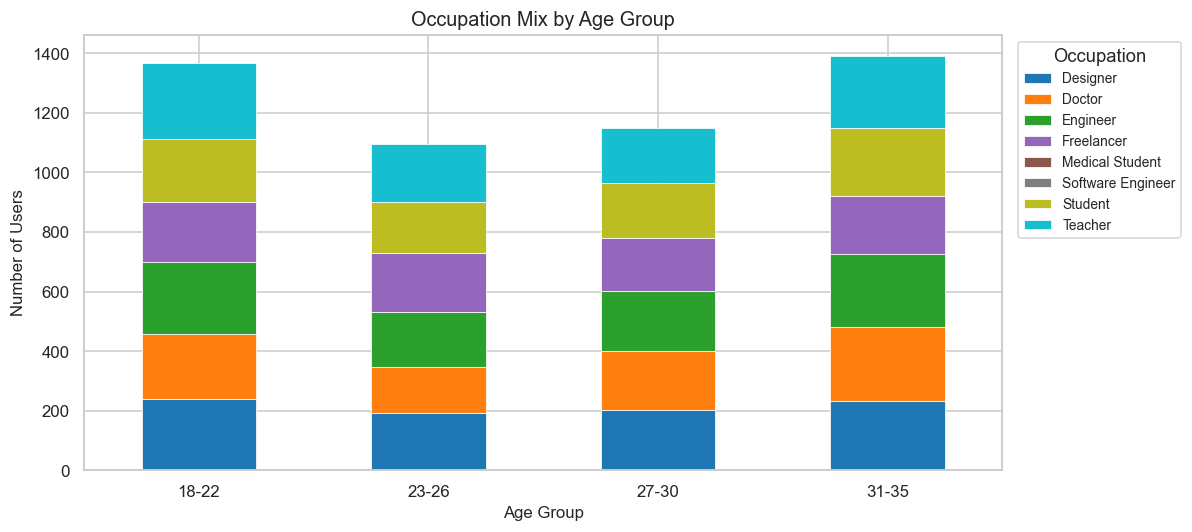

In [29]:
 
df['age_group'] = pd.cut(df['age'], bins=[17,22,26,30,35],
                          labels=['18-22','23-26','27-30','31-35'])

age_occ = df.groupby(['age_group', 'occupation'], observed=True).size().unstack(fill_value=0)

age_occ.plot(kind='bar', stacked=True, figsize=(11, 5),
             colormap='tab10', edgecolor='white', linewidth=0.5)
plt.title('Occupation Mix by Age Group', fontsize=13)
plt.xlabel('Age Group')
plt.ylabel('Number of Users')
plt.xticks(rotation=0)
plt.legend(title='Occupation', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

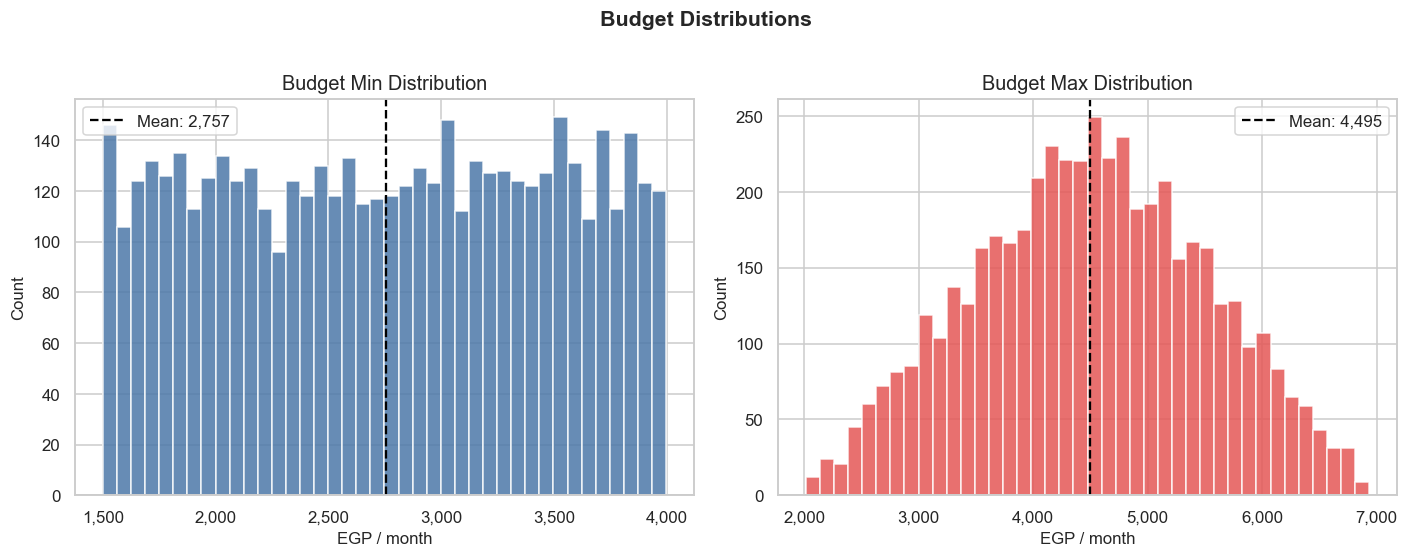

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, color, label in zip(
    axes,
    ['budget_min', 'budget_max'],
    [BLUE, CORAL],
    ['Budget Min', 'Budget Max']
):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean: {df[col].mean():,.0f}')
    ax.set_title(f'{label} Distribution')
    ax.set_xlabel('EGP / month')
    ax.set_ylabel('Count')
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Budget Distributions', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

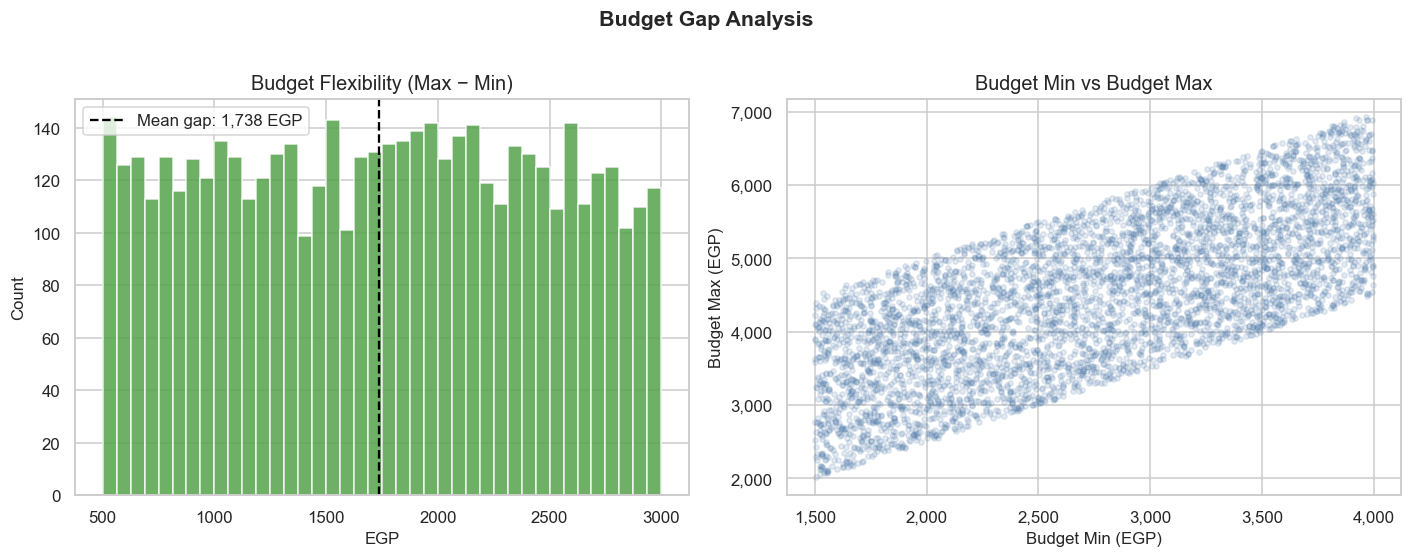

Average budget gap : 1,738 EGP
Min gap            : 500 EGP
Max gap            : 3,000 EGP


In [31]:
df['budget_gap'] = df['budget_max'] - df['budget_min']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['budget_gap'], bins=40, color=GREEN, edgecolor='white', alpha=0.85)
axes[0].axvline(df['budget_gap'].mean(), color='black', linestyle='--', linewidth=1.5,
                label=f"Mean gap: {df['budget_gap'].mean():,.0f} EGP")
axes[0].set_title('Budget Flexibility (Max − Min)')
axes[0].set_xlabel('EGP')
axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].scatter(df['budget_min'], df['budget_max'], alpha=0.15, color=BLUE, s=12)
axes[1].set_title('Budget Min vs Budget Max')
axes[1].set_xlabel('Budget Min (EGP)')
axes[1].set_ylabel('Budget Max (EGP)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

plt.suptitle('Budget Gap Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Average budget gap : {df['budget_gap'].mean():,.0f} EGP")
print(f"Min gap            : {df['budget_gap'].min():,.0f} EGP")
print(f"Max gap            : {df['budget_gap'].max():,.0f} EGP")

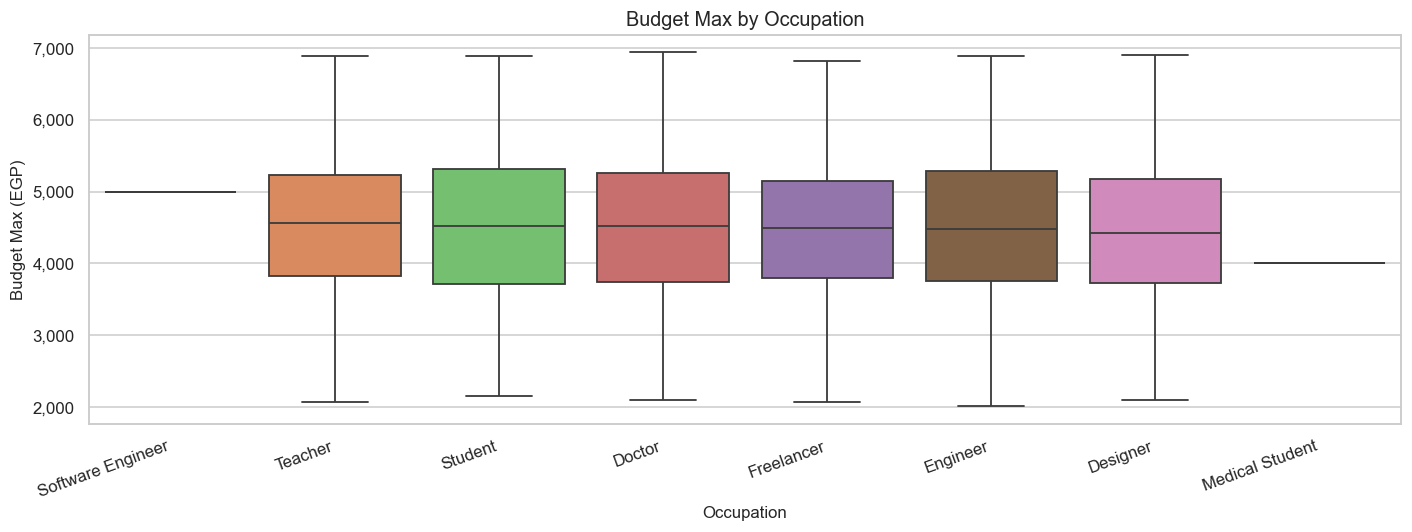

In [32]:
occ_order = df.groupby('occupation')['budget_max'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 5))
sns.boxplot(data=df, x='occupation', y='budget_max', order=occ_order,
            palette='muted', ax=ax, linewidth=1.2)
ax.set_title('Budget Max by Occupation')
ax.set_xlabel('Occupation')
ax.set_ylabel('Budget Max (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

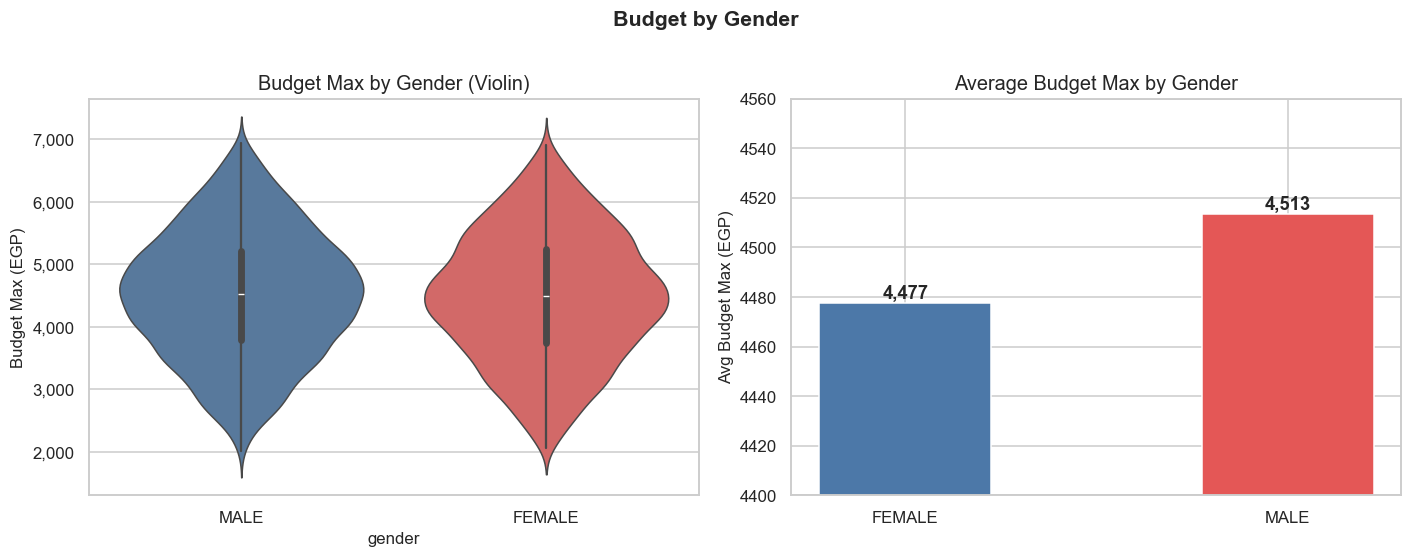

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.violinplot(data=df, x='gender', y='budget_max',
               palette=[BLUE, CORAL], ax=axes[0], inner='box', linewidth=1)
axes[0].set_title('Budget Max by Gender (Violin)')
axes[0].set_ylabel('Budget Max (EGP)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

gender_budget = df.groupby('gender')['budget_max'].mean()
bars = axes[1].bar(gender_budget.index, gender_budget.values,
                   color=[BLUE, CORAL], edgecolor='white', width=0.45)
axes[1].set_title('Average Budget Max by Gender')
axes[1].set_ylabel('Avg Budget Max (EGP)')
axes[1].set_ylim(4400, 4560)
for bar, val in zip(bars, gender_budget.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 2,
                 f'{val:,.0f}', ha='center', fontweight='bold')

plt.suptitle('Budget by Gender', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

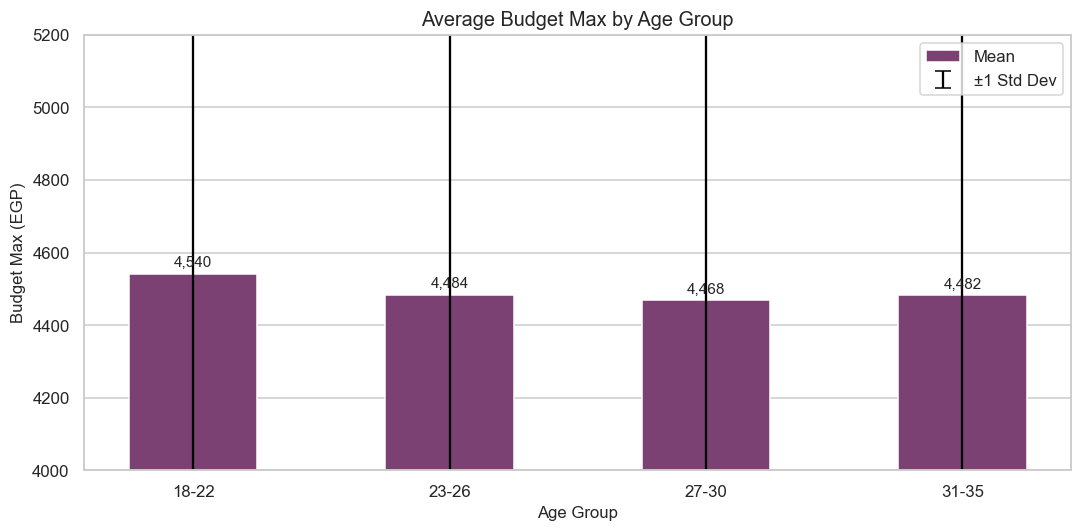

In [45]:
age_budget = df.groupby('age_group', observed=True)['budget_max'].agg(['mean','median','std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(age_budget))
bars = ax.bar(x, age_budget['mean'], color=PURPLE, edgecolor='white', width=0.5, label='Mean')
ax.errorbar(x, age_budget['mean'], yerr=age_budget['std'],
            fmt='none', color='black', capsize=5, linewidth=1.5, label='±1 Std Dev')
ax.set_xticks(x)
ax.set_xticklabels(age_budget['age_group'])
ax.set_title('Average Budget Max by Age Group')
ax.set_xlabel('Age Group')
ax.set_ylabel('Budget Max (EGP)')
ax.set_ylim(4000, 5200)
ax.legend()
for bar, val in zip(bars, age_budget['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, f'{val:,.0f}',
            ha='center', fontsize=10)
plt.tight_layout()
plt.show()

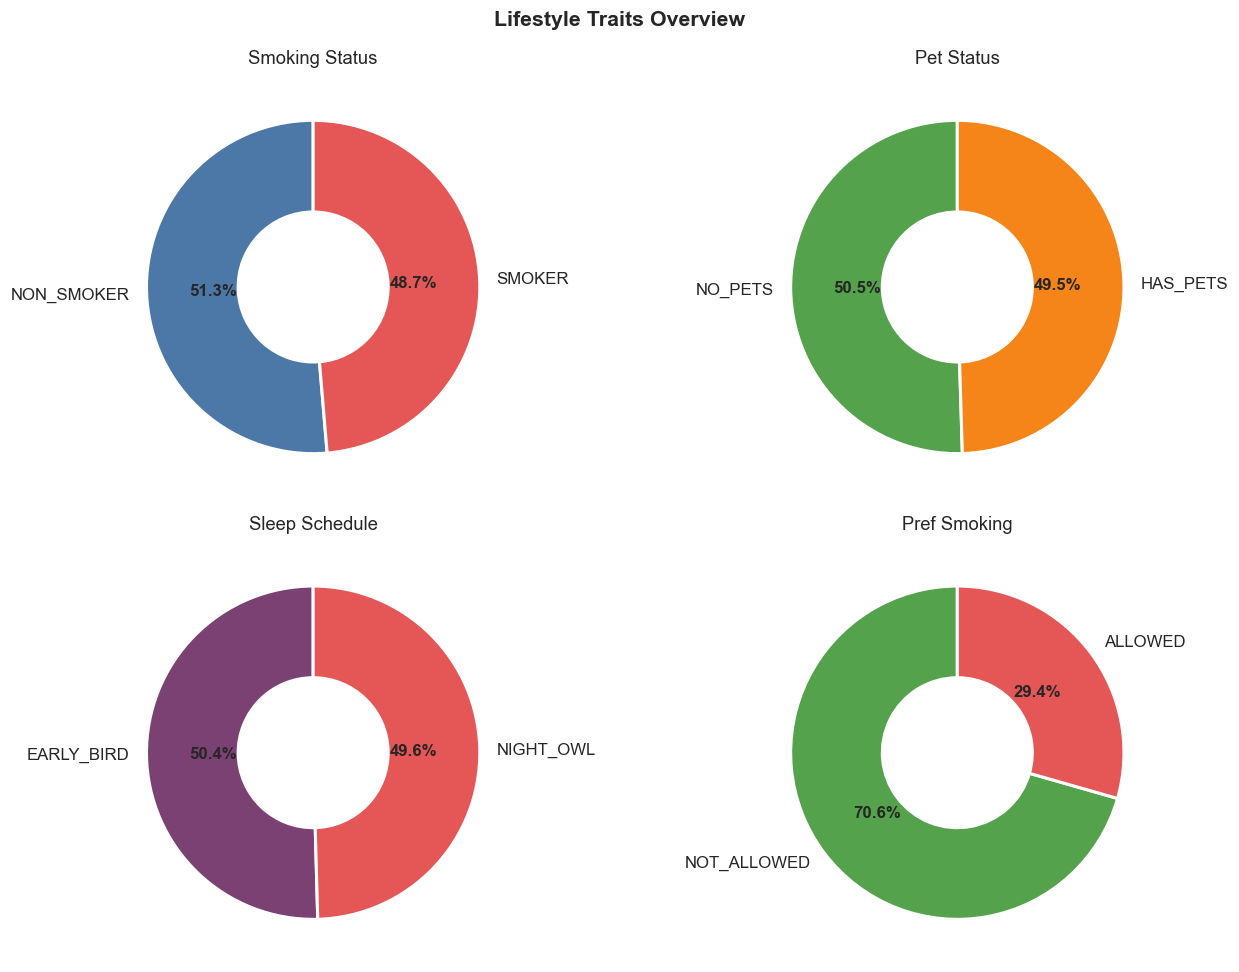

In [44]:
lifestyle_cols = {
    'smoking_status'  : ('Smoking Status',  [BLUE, CORAL]),
    'pet_status'      : ('Pet Status',       [GREEN, AMBER]),
    'sleep_schedule'  : ('Sleep Schedule',   [PURPLE, CORAL]),
    'pref_smoking'    : ('Pref Smoking',     [GREEN, CORAL]),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (col, (title, colors)) in zip(axes, lifestyle_cols.items()):
    counts = df[col].value_counts()
    wedges, texts, autotexts = ax.pie(
        counts, labels=counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90,
        wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2}
    )
    for t in autotexts:
        t.set_fontsize(11)
        t.set_fontweight('bold')
    ax.set_title(title, fontsize=12, pad=10)

plt.suptitle('Lifestyle Traits Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

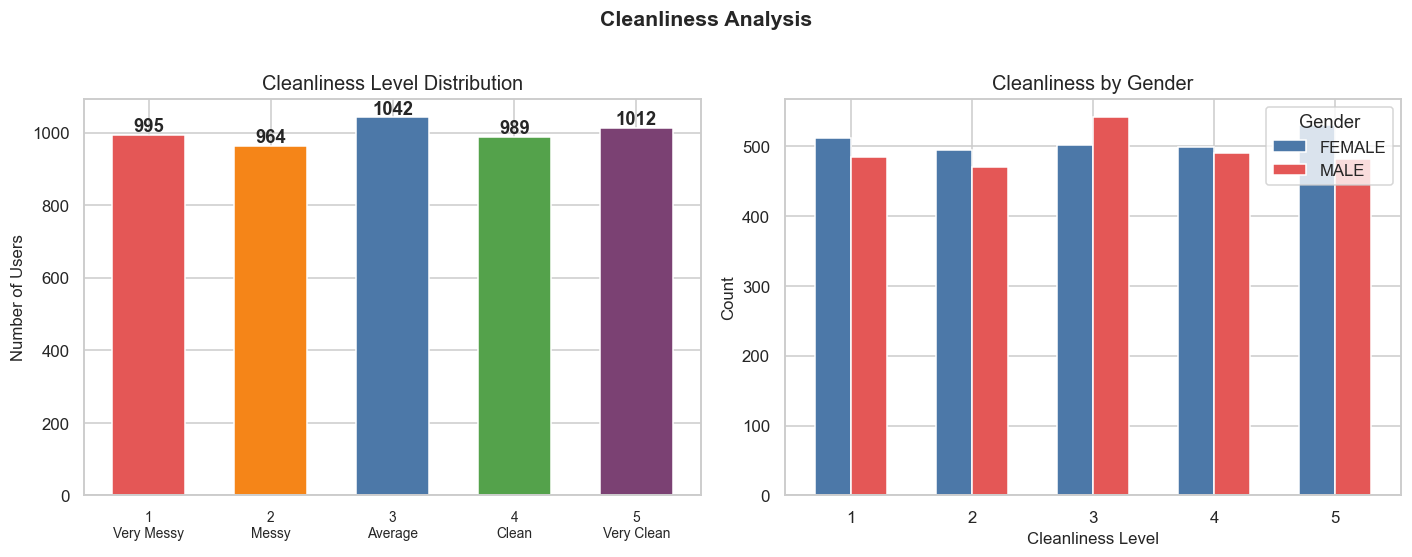

In [43]:
clean_counts = df['cleanliness'].value_counts().sort_index()
clean_labels = {1: 'Very Messy', 2: 'Messy', 3: 'Average', 4: 'Clean', 5: 'Very Clean'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

bar_colors = [CORAL, AMBER, BLUE, GREEN, PURPLE]
bars = axes[0].bar(clean_counts.index, clean_counts.values,
                   color=bar_colors, edgecolor='white', width=0.6)
axes[0].set_xticks(range(1, 6))
axes[0].set_xticklabels([f"{i}\n{clean_labels[i]}" for i in range(1, 6)], fontsize=9)
axes[0].set_title('Cleanliness Level Distribution')
axes[0].set_ylabel('Number of Users')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(bar.get_height()), ha='center', fontweight='bold')

# Cleanliness split by gender
clean_gender = df.groupby(['cleanliness', 'gender']).size().unstack()
clean_gender.plot(kind='bar', ax=axes[1], color=[BLUE, CORAL], edgecolor='white', width=0.6)
axes[1].set_title('Cleanliness by Gender')
axes[1].set_xlabel('Cleanliness Level')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(range(1, 6), rotation=0)
axes[1].legend(title='Gender')

plt.suptitle('Cleanliness Analysis', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

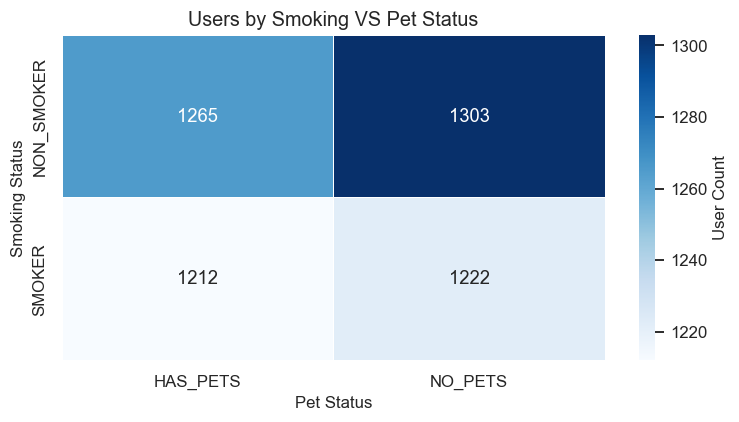

In [42]:
combo = df.groupby(['smoking_status', 'pet_status']).size().unstack()

plt.figure(figsize=(7, 4))
sns.heatmap(combo, annot=True, fmt='d', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': 'User Count'})
plt.title('Users by Smoking VS Pet Status')
plt.xlabel('Pet Status')
plt.ylabel('Smoking Status')
plt.tight_layout()
plt.show()

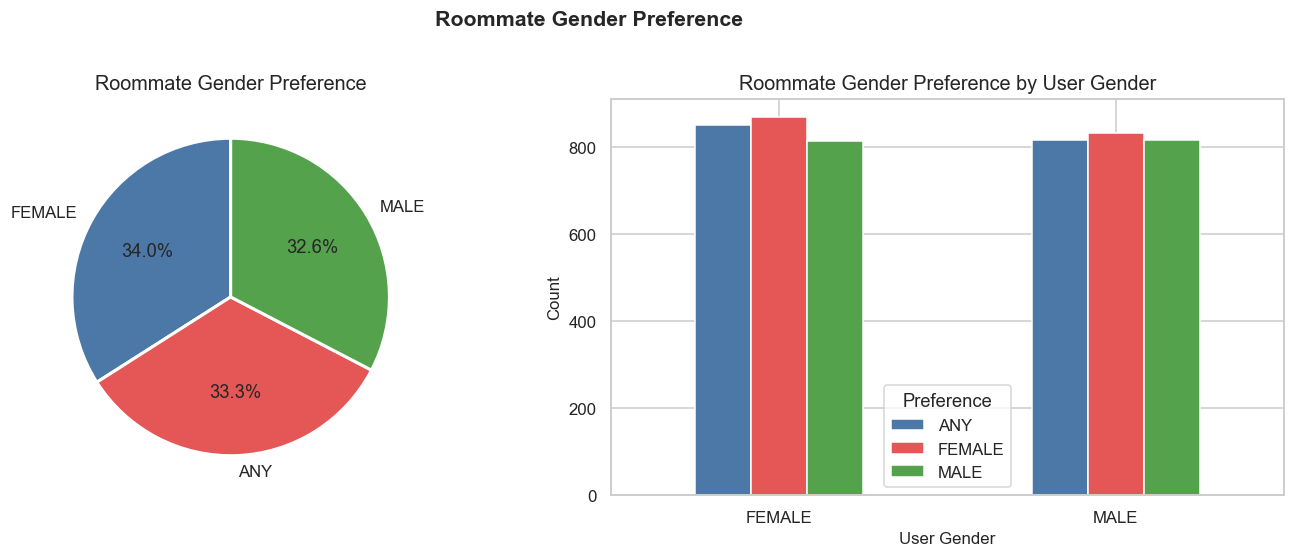

In [41]:
pref_counts = df['roommate_gender_pref'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].pie(pref_counts, labels=pref_counts.index, autopct='%1.1f%%',
            colors=[BLUE, CORAL, GREEN], startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Roommate Gender Preference')

# Preference split by user gender
pref_gender = df.groupby(['gender', 'roommate_gender_pref']).size().unstack(fill_value=0)
pref_gender.plot(kind='bar', ax=axes[1], color=[BLUE, CORAL, GREEN],
                 edgecolor='white', width=0.5)
axes[1].set_title('Roommate Gender Preference by User Gender')
axes[1].set_xlabel('User Gender')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Preference')

plt.suptitle('Roommate Gender Preference', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

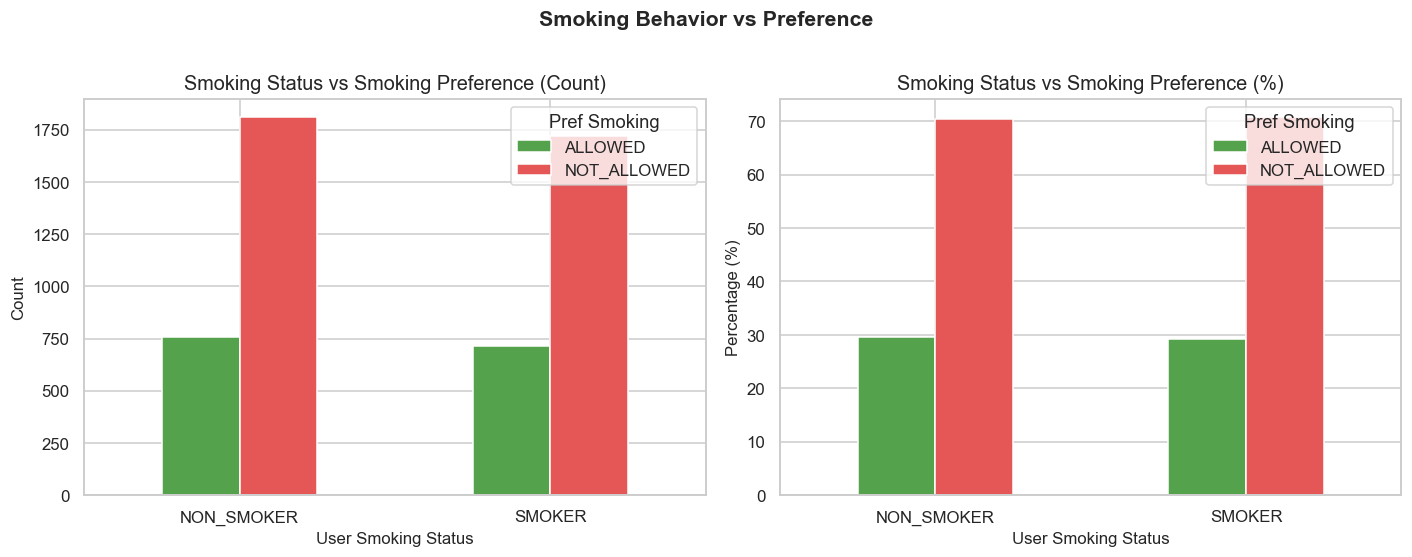

In [40]:
cross = pd.crosstab(df['smoking_status'], df['pref_smoking'])
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cross.plot(kind='bar', ax=axes[0], color=[GREEN, CORAL], edgecolor='white', width=0.5)
axes[0].set_title('Smoking Status vs Smoking Preference (Count)')
axes[0].set_xlabel('User Smoking Status')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Pref Smoking')

cross_pct.plot(kind='bar', ax=axes[1], color=[GREEN, CORAL], edgecolor='white', width=0.5)
axes[1].set_title('Smoking Status vs Smoking Preference (%)')
axes[1].set_xlabel('User Smoking Status')
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Pref Smoking')

plt.suptitle('Smoking Behavior vs Preference', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

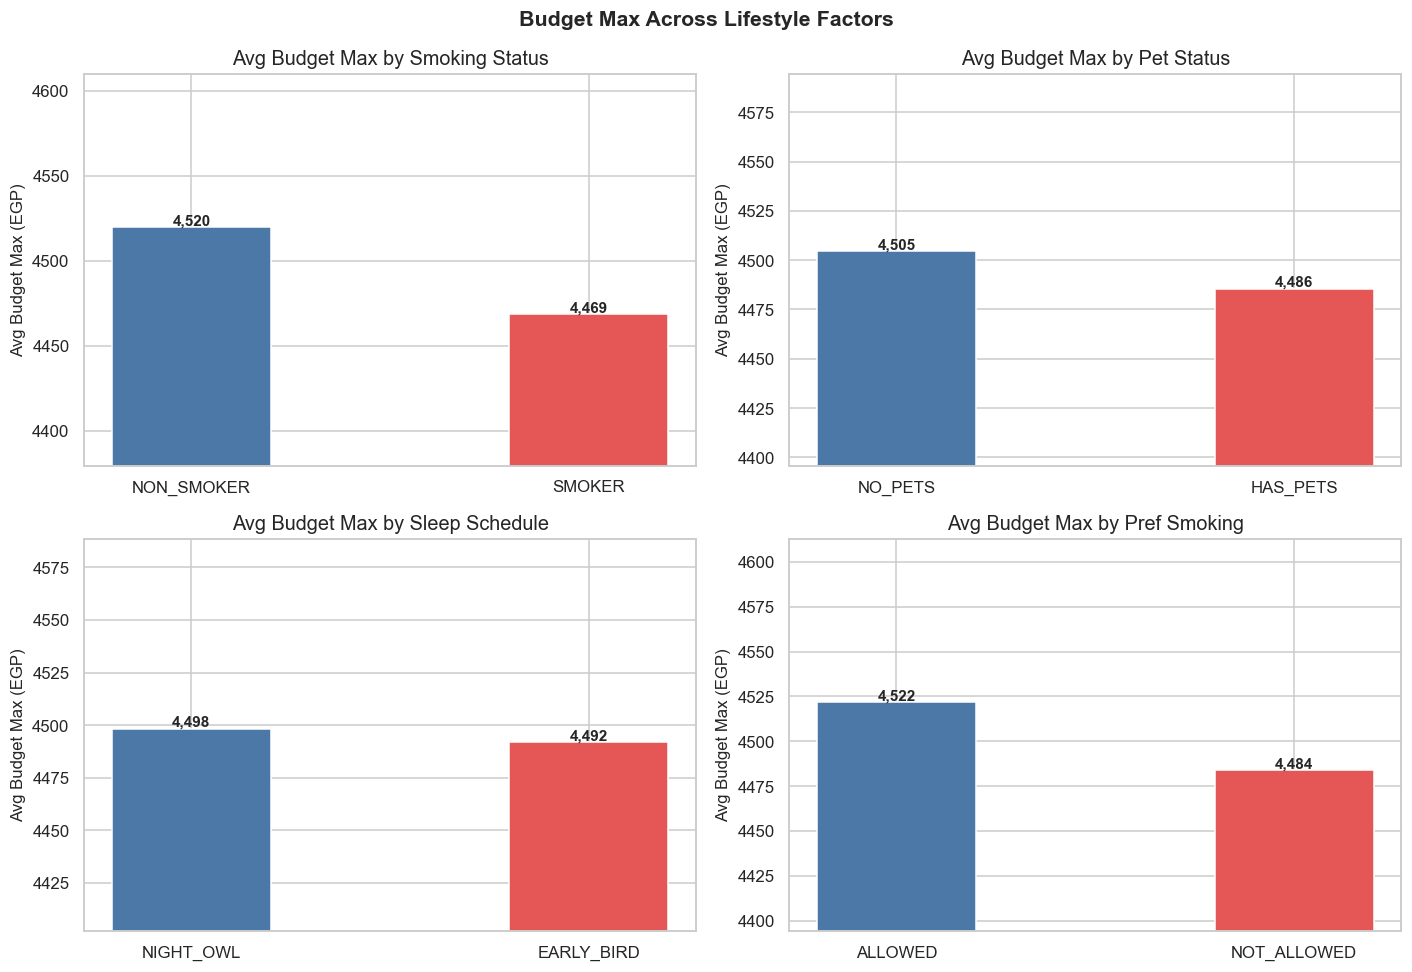

In [33]:
factors = ['smoking_status', 'pet_status', 'sleep_schedule', 'pref_smoking']
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, col in zip(axes, factors):
    grp = df.groupby(col)['budget_max'].mean().sort_values(ascending=False)
    bars = ax.bar(grp.index, grp.values, color=[BLUE, CORAL], edgecolor='white', width=0.4)
    ax.set_title(f'Avg Budget Max by {col.replace("_"," ").title()}')
    ax.set_ylabel('Avg Budget Max (EGP)')
    ax.set_ylim(grp.min() * 0.98, grp.max() * 1.02)
    for bar, val in zip(bars, grp.values):
        ax.text(bar.get_x() + bar.get_width()/2, val + 1,
                f'{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Budget Max Across Lifestyle Factors', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

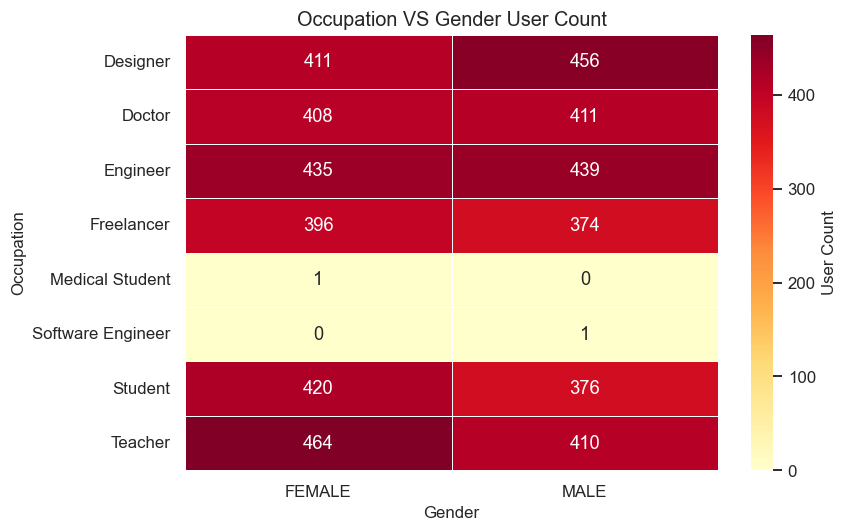

In [34]:
occ_gender = df.groupby(['occupation', 'gender']).size().unstack(fill_value=0)

plt.figure(figsize=(8, 5))
sns.heatmap(occ_gender, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'User Count'})
plt.title('Occupation VS Gender User Count')
plt.xlabel('Gender')
plt.ylabel('Occupation')
plt.tight_layout()
plt.show()

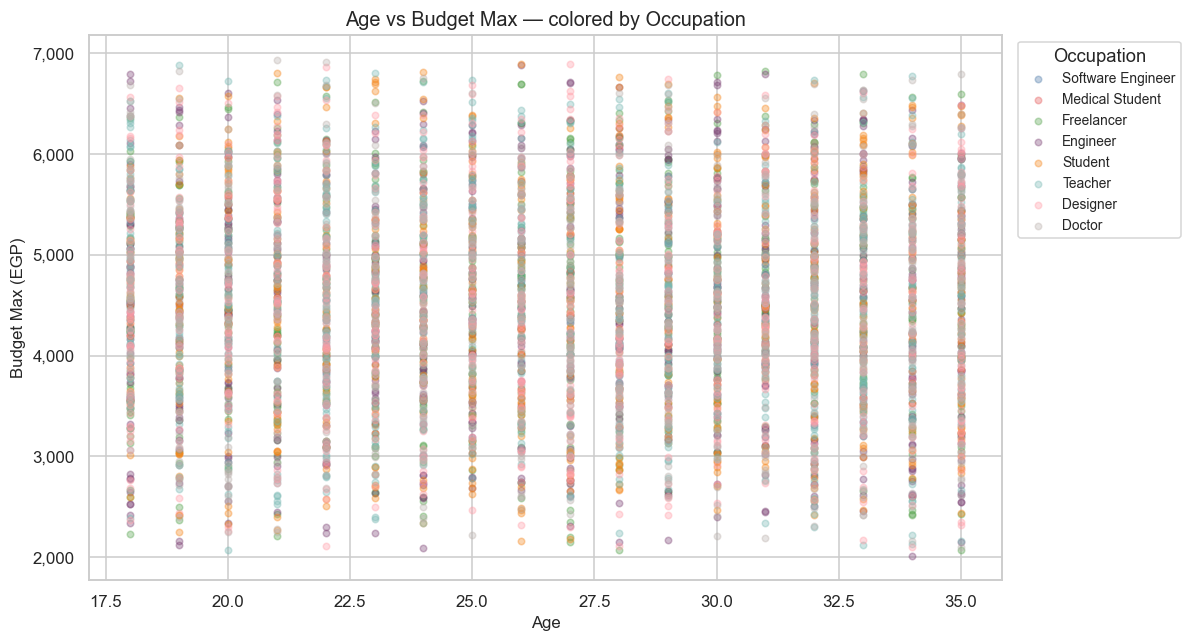

In [35]:
occ_list = df['occupation'].unique()
occ_colors = dict(zip(occ_list, ['#4C78A8','#E45756','#54A24B','#7B4173',
                                   '#F58518','#76B7B2','#FF9DA7','#BAB0AC']))

fig, ax = plt.subplots(figsize=(11, 6))
for occ in occ_list:
    subset = df[df['occupation'] == occ]
    ax.scatter(subset['age'], subset['budget_max'],
               label=occ, alpha=0.35, s=18, color=occ_colors[occ])

ax.set_title('Age vs Budget Max — colored by Occupation')
ax.set_xlabel('Age')
ax.set_ylabel('Budget Max (EGP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.legend(title='Occupation', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

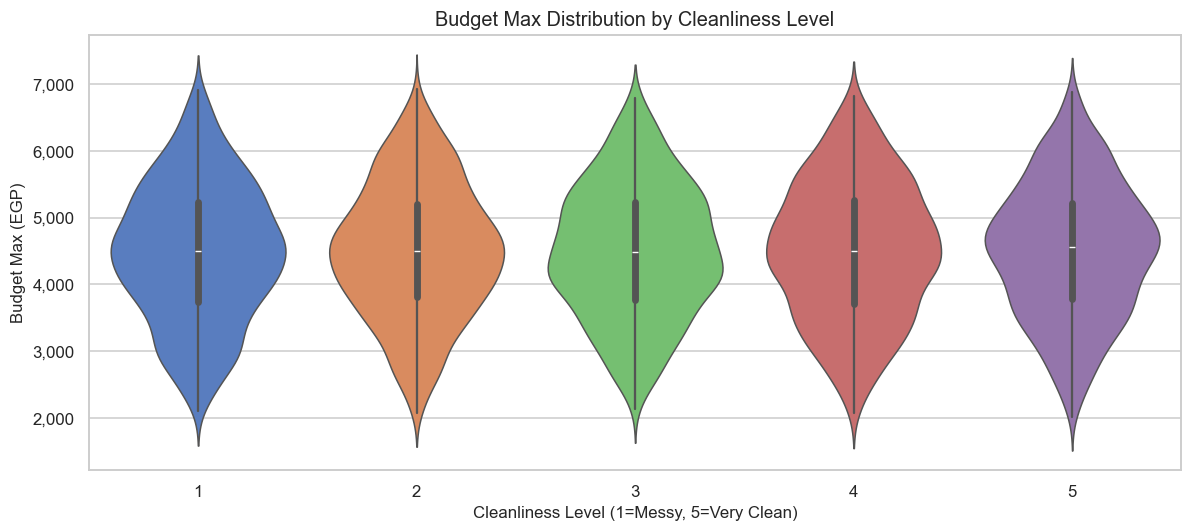

In [36]:
plt.figure(figsize=(11, 5))
sns.violinplot(data=df, x='cleanliness', y='budget_max',
               palette='muted', inner='box', linewidth=1)
plt.title('Budget Max Distribution by Cleanliness Level')
plt.xlabel('Cleanliness Level (1=Messy, 5=Very Clean)')
plt.ylabel('Budget Max (EGP)')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
plt.tight_layout()
plt.show()

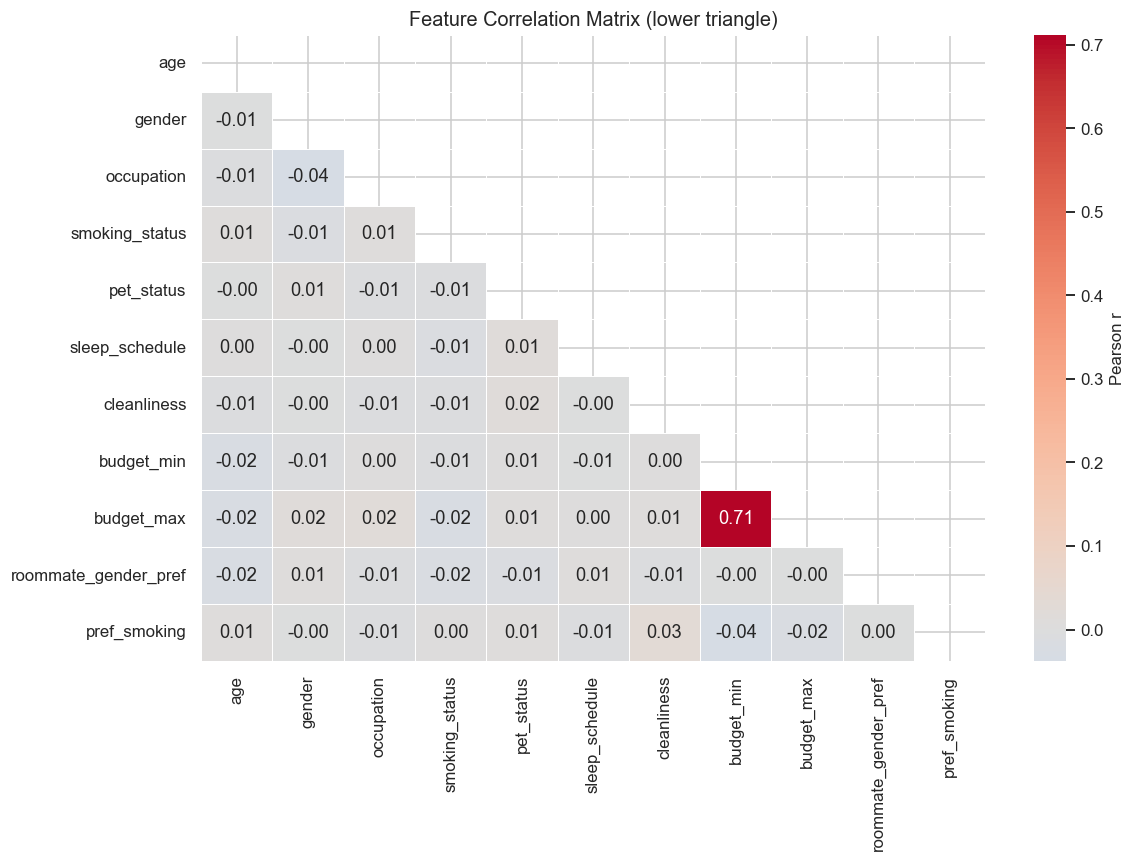

In [37]:
from sklearn.preprocessing import LabelEncoder

df_enc = df.drop(columns=['user_id','age_group','budget_gap'], errors='ignore').copy()
le = LabelEncoder()
cat_cols = df_enc.select_dtypes(exclude=np.number).columns
for col in cat_cols:
    df_enc[col] = le.fit_transform(df_enc[col])

corr = df_enc.corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5,
            cbar_kws={'label': 'Pearson r'})
plt.title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

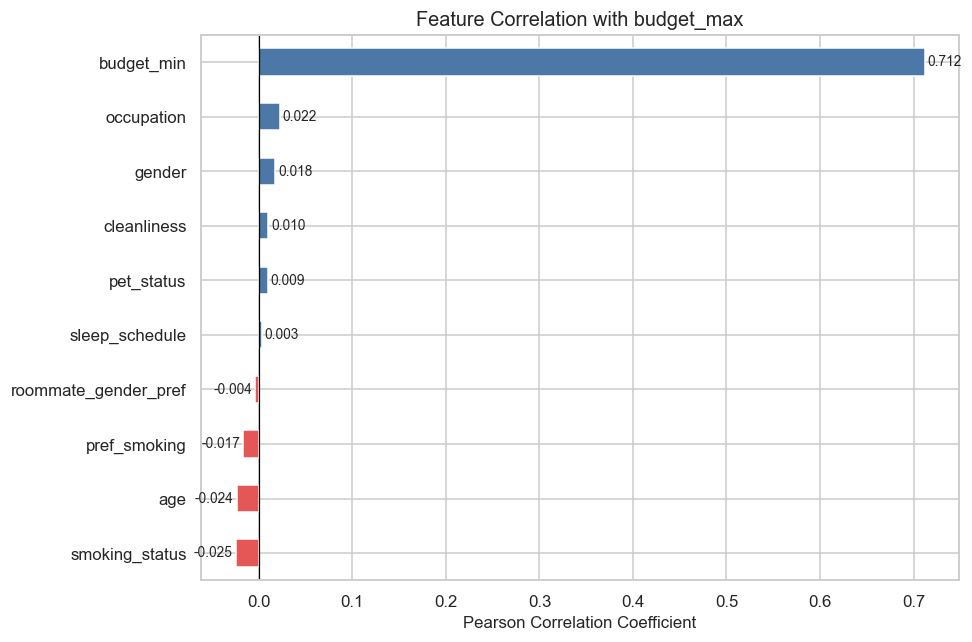

In [38]:
target_corr = corr['budget_max'].drop('budget_max').sort_values()

colors_bar = [CORAL if v < 0 else BLUE for v in target_corr.values]

fig, ax = plt.subplots(figsize=(9, 6))
target_corr.plot(kind='barh', ax=ax, color=colors_bar, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Feature Correlation with budget_max')
ax.set_xlabel('Pearson Correlation Coefficient')
for i, (val, label) in enumerate(zip(target_corr.values, target_corr.index)):
    ax.text(val + (0.003 if val >= 0 else -0.003), i,
            f'{val:.3f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

In [39]:
print('=' * 55)
print('KEY TAKEAWAYS — ROOMMATE DATASET')
print('=' * 55)

print(f"""
 DEMOGRAPHICS
   • {len(df):,} users total — nearly balanced gender split
     (Female {df['gender'].value_counts()['FEMALE']:,} | Male {df['gender'].value_counts()['MALE']:,})
   • Age range 18–35, avg {df['age'].mean():.1f} yrs — young adult platform
   • Top occupations: Engineer, Teacher, Designer, Doctor

 BUDGET
   • Avg budget_max = {df['budget_max'].mean():,.0f} EGP/month
   • Avg budget_min = {df['budget_min'].mean():,.0f} EGP/month
   • Avg flexibility gap = {df['budget_gap'].mean():,.0f} EGP
   • budget_min is the strongest predictor of budget_max

 LIFESTYLE
   • Most users are NON_SMOKERS and prefer NO smoking allowed
   • Most users have NO_PETS
   • Cleanliness is fairly evenly distributed (avg ≈ 3.0)

 PREFERENCES
   • Many users accept ANY gender as a roommate — good for matching
   • Smokers are more flexible about smoking preference than expected

 MODEL INSIGHT
   • budget_min has the highest correlation with budget_max
   • Lifestyle & demographic features have low individual correlation
     but contribute collectively to the Random Forest model
""")
print('=' * 55)

KEY TAKEAWAYS — ROOMMATE DATASET

 DEMOGRAPHICS
   • 5,002 users total — nearly balanced gender split
     (Female 2,535 | Male 2,467)
   • Age range 18–35, avg 26.6 yrs — young adult platform
   • Top occupations: Engineer, Teacher, Designer, Doctor

 BUDGET
   • Avg budget_max = 4,495 EGP/month
   • Avg budget_min = 2,757 EGP/month
   • Avg flexibility gap = 1,738 EGP
   • budget_min is the strongest predictor of budget_max

 LIFESTYLE
   • Most users are NON_SMOKERS and prefer NO smoking allowed
   • Most users have NO_PETS
   • Cleanliness is fairly evenly distributed (avg ≈ 3.0)

 PREFERENCES
   • Many users accept ANY gender as a roommate — good for matching
   • Smokers are more flexible about smoking preference than expected

 MODEL INSIGHT
   • budget_min has the highest correlation with budget_max
   • Lifestyle & demographic features have low individual correlation
     but contribute collectively to the Random Forest model

